# Spotify — Hit Predictor: Optimal Feature Values for Future Music
**What audio features will make the best music going forward?**  
This notebook extrapolates historical trends to predict ideal future values, builds a regression model, and creates a scoring tool you can use to evaluate any song concept.


## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

df_at = pd.read_csv('/content/drive/MyDrive/Kaggle/Spotify/Spotify_Songs_Data/spotify_alltime_top100_songs.csv')
df_art = pd.read_csv('/content/drive/MyDrive/Kaggle/Spotify/Spotify_Songs_Data/spotify_wrapped_2025_top50_artists.csv')
df_25 = pd.read_csv('/content/drive/MyDrive/Kaggle/Spotify/Spotify_Songs_Data/spotify_wrapped_2025_top50_songs.csv')

features = ['danceability', 'energy', 'valence', 'acousticness']

## 2. Trend Extrapolation

In [24]:
recent = df_at[df_at['release_year'] >= 2012].copy()
year_means = recent.groupby('release_year')[features + ['bpm']].mean()

# Add 2025 actual
row_2025 = df_25[features + ['bpm']].mean()
row_2025.name = 2025
year_means = pd.concat([year_means, row_2025.to_frame().T])
year_means.index = year_means.index.astype(int)

# Fit linear trends for each feature
future_years = [2026, 2027, 2028]
all_years_ext = list(year_means.index) + future_years
trend_results = {}

for feat in features + ['bpm']:
    x = year_means.index.values.reshape(-1, 1)
    y = year_means[feat].values
    lr = LinearRegression().fit(x, y)
    slope = lr.coef_[0]
    r2 = r2_score(y, lr.predict(x))
    future_vals = lr.predict(np.array(future_years).reshape(-1, 1))
    if feat != 'bpm':
        future_vals = np.clip(future_vals, 0, 1)
    else:
        future_vals = np.clip(future_vals, 60, 180)
    trend_results[feat] = {'slope': slope, 'r2': r2, 'future': dict(zip(future_years, future_vals))}

print(f'{"Feature":<15} {"Slope/yr":>10} {"R squared":>8} {"2026 pred":>12} {"2027 pred":>12} {"2028 pred":>12}')
print('-' * 72)
for feat, res in trend_results.items():
    f26 = res['future'][2026]
    f27 = res['future'][2027]
    f28 = res['future'][2028]
    print(f'{feat:<15} {res["slope"]:+10.4f} {res["r2"]:8.3f} {f26:12.3f} {f27:12.3f} {f28:12.3f}')

Feature           Slope/yr R squared    2026 pred    2027 pred    2028 pred
------------------------------------------------------------------------
danceability       +0.0129    0.421        0.709        0.722        0.735
energy             +0.0022    0.011        0.638        0.641        0.643
valence            +0.0202    0.478        0.709        0.729        0.749
acousticness       -0.0068    0.093        0.121        0.114        0.107
bpm                -0.4882    0.031      109.428      108.940      108.452


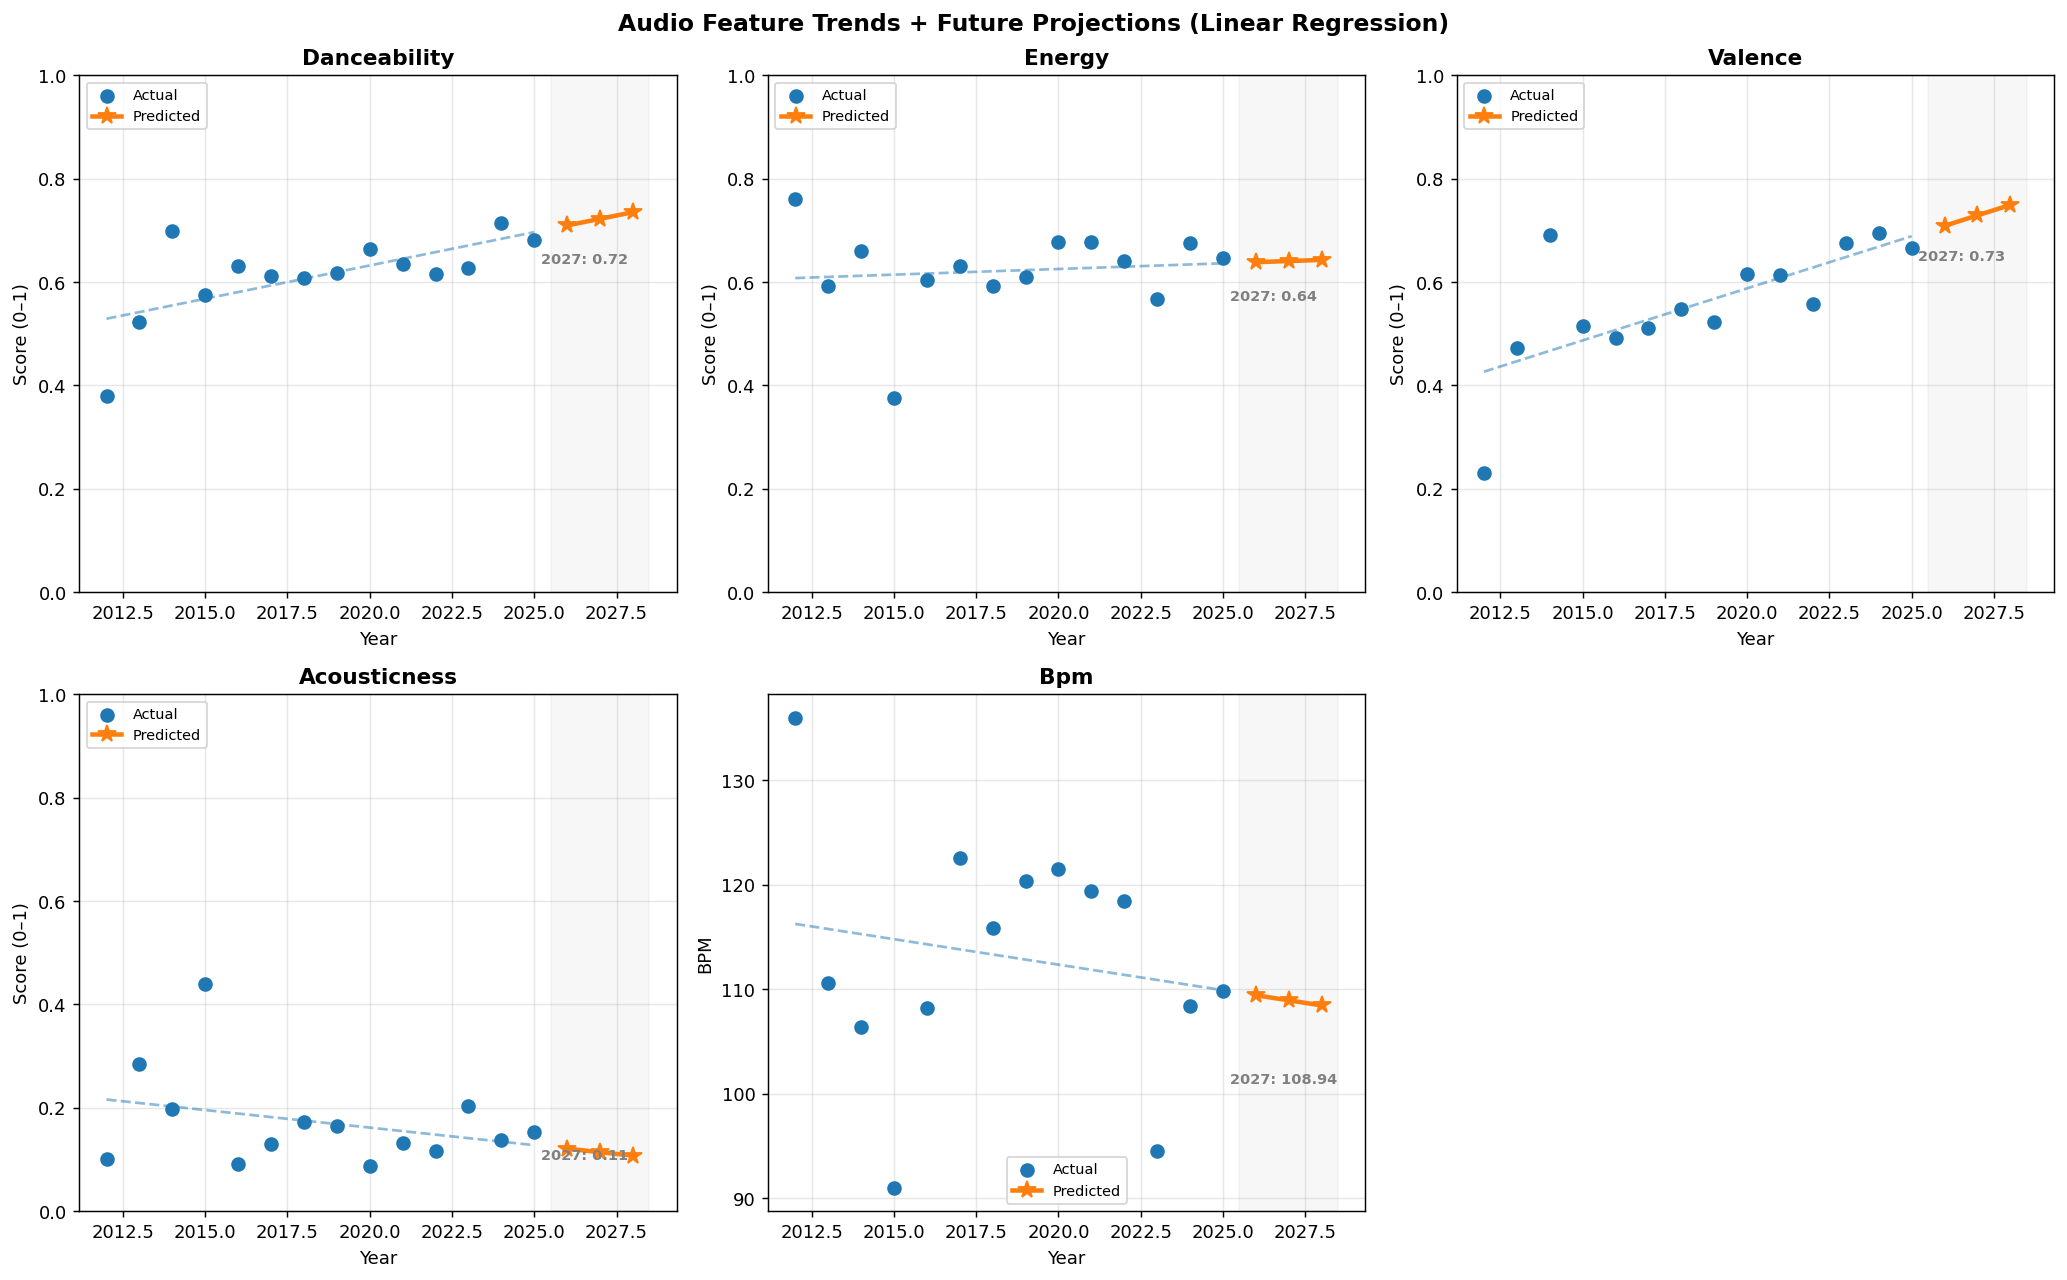

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Audio Feature Trends + Future Projections (Linear Regression)', fontsize=13, fontweight='bold')
all_feats = features + ['bpm']

for ax, feat in zip(axes.flatten(), all_feats):
    # Historical actuals
    x_hist = year_means.index.values
    y_hist = year_means[feat].values
    ax.scatter(x_hist, y_hist, s=50, zorder=5, label='Actual')

    # Trend line (full range)
    x_full = np.array(list(x_hist) + future_years)
    lr = LinearRegression().fit(x_hist.reshape(-1,1), y_hist)
    y_trend = lr.predict(x_full.reshape(-1,1))
    if feat != 'bpm':
        y_trend = np.clip(y_trend, 0, 1)
    ax.plot(x_full[:len(x_hist)], y_trend[:len(x_hist)], lw=1.5, alpha=0.5, linestyle='--')

    # Future predictions
    y_fut = y_trend[len(x_hist):]
    ax.plot(future_years, y_fut, lw=2.5, linestyle='-', marker='*', markersize=10, label='Predicted')
    ax.axvspan(2025.5, 2028.5, alpha=0.06, color='gray')

    ax.set_title(feat.capitalize(), fontweight='bold')
    ax.set_xlabel('Year')
    if feat != 'bpm':
        ax.set_ylim(0, 1)
        ax.set_ylabel('Score (0–1)')
    else:
        ax.set_ylabel('BPM')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Annotate 2027 prediction
    ax.annotate(f'2027: {trend_results[feat]["future"][2027]:.2f}',
                xy=(2027, trend_results[feat]['future'][2027]),
                xytext=(2025.2, trend_results[feat]['future'][2027] * 0.88 if feat != 'bpm' else trend_results[feat]['future'][2027] - 8),
                fontsize=8, color='gray', fontweight='bold')

axes[1, 2].set_visible(False)
plt.tight_layout()
plt.savefig('feature_projections.png', bbox_inches='tight')
plt.show()

## 3. ML Regression — Predicting Stream Count

In [26]:
# Combine all-time + 2025 for regression
df_at_r = df_at[features + ['bpm', 'total_streams_billions']].copy().rename(columns={'total_streams_billions':'streams'})
df_25_r = df_25[features + ['bpm', 'streams_2025_billions']].copy().rename(columns={'streams_2025_billions':'streams'})
df_all = pd.concat([df_at_r, df_25_r], ignore_index=True).dropna()

X = df_all[features + ['bpm']]
y = df_all['streams']

models = {
    'Ridge Regression': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scl', StandardScaler()),
        ('clf', Ridge(alpha=1.0))
    ]),
    'Random Forest': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', RandomForestRegressor(n_estimators=200, random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', GradientBoostingRegressor(n_estimators=200, random_state=42))
    ])
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print('=== Model Performance (5-Fold CV) ===')
print(f'{"Model":<22} {"CV R²":>10} {"± Std":>8}')
print('-' * 44)
for name, pipe in models.items():
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='r2')
    results[name] = {'pipe': pipe, 'cv_r2': scores.mean(), 'cv_std': scores.std()}
    print(f'{name:<22} {scores.mean():>10.4f} {scores.std():>8.4f}')

best_name = max(results, key=lambda k: results[k]['cv_r2'])
print(f'\n Best model: {best_name}')

=== Model Performance (5-Fold CV) ===
Model                       CV R²    ± Std
--------------------------------------------
Ridge Regression          -0.0307   0.1712
Random Forest             -0.0185   0.1012
Gradient Boosting         -0.1226   0.1543

 Best model: Random Forest


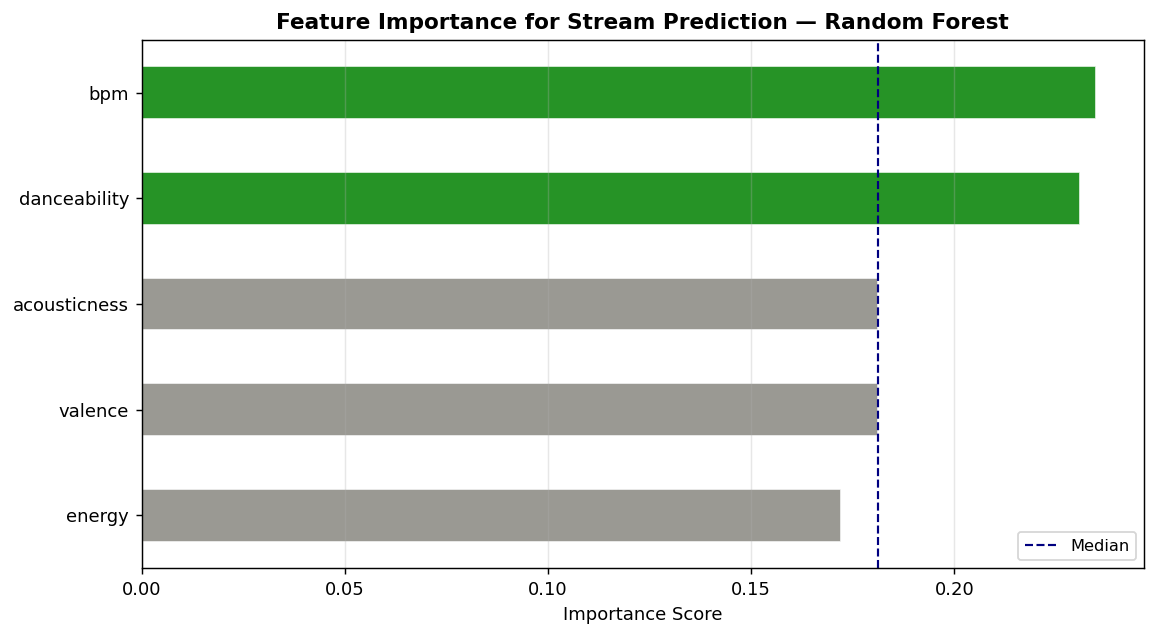

In [27]:
# Train best model on full data
best_pipe = results[best_name]['pipe']
best_pipe.fit(X, y)

# Feature importance (Random Forest or GB)
if hasattr(best_pipe.named_steps['clf'], 'feature_importances_'):
    imps = best_pipe.named_steps['clf'].feature_importances_
    feat_imp = pd.Series(imps, index=features + ['bpm']).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(9, 5))
    colors_imp = ['green' if v > feat_imp.median() else '#888780' for v in feat_imp]
    feat_imp.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white', alpha=0.85)
    ax.set_title(f'Feature Importance for Stream Prediction — {best_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.axvline(feat_imp.median(), color='navy', linestyle='--', lw=1.2, label='Median')
    ax.legend(fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('feature_importance_streams.png', bbox_inches='tight')
    plt.show()

## 4. Predicted Optimal Values by Year

In [28]:
optimal = {}
for yr in [2026, 2027, 2028]:
    row = {feat: trend_results[feat]['future'][yr] for feat in features}
    row['bpm'] = trend_results['bpm']['future'][yr]
    optimal[yr] = row

optimal_df = pd.DataFrame(optimal).T.round(3)
optimal_df.index.name = 'Year'
print('=== Predicted Optimal Audio Feature Values ===')
display(optimal_df.style.background_gradient(axis=0))

=== Predicted Optimal Audio Feature Values ===


,danceability,energy,valence,acousticness,bpm
Year,,,,,
2026,0.709000,0.638000,0.709000,0.121000,109.428000
2027,0.722000,0.641000,0.729000,0.114000,108.940000
2028,0.735000,0.643000,0.749000,0.107000,108.452000


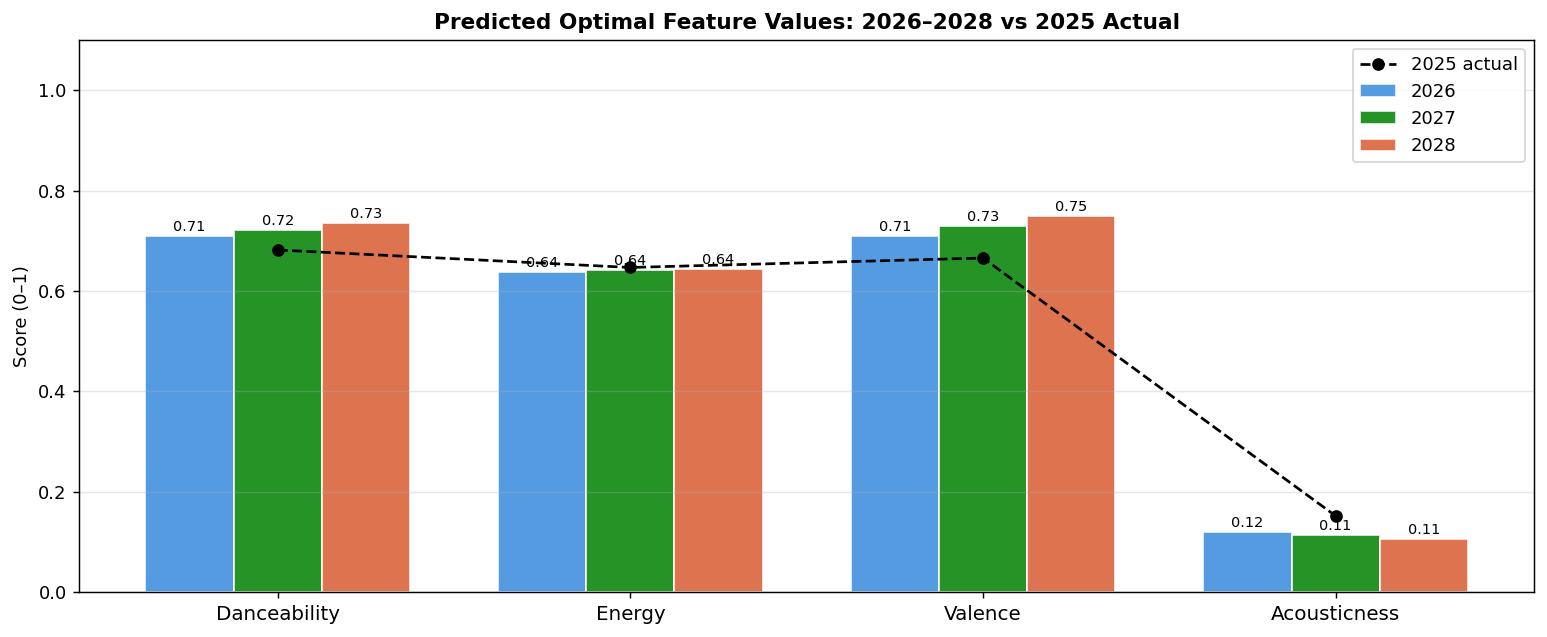

In [29]:
# Visualize optimal targets
fig, ax = plt.subplots(figsize=(12, 5))

years_pred = [2026, 2027, 2028]
x = np.arange(len(features))
w = 0.25
offsets = [-w, 0, w]
yr_colors = ['#378ADD', 'green', '#D85A30']

for i, (yr, color) in enumerate(zip(years_pred, yr_colors)):
    vals = [optimal_df.loc[yr, f] for f in features]
    bars = ax.bar(x + offsets[i], vals, w, label=str(yr), color=color, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.2f}', ha='center', fontsize=8)

# Overlay 2025 actuals
act_vals = [df_25[f].mean() for f in features]
ax.plot(x, act_vals, 'k--o', lw=1.5, ms=6, label='2025 actual', zorder=5)

ax.set_xticks(x)
ax.set_xticklabels([f.capitalize() for f in features], fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score (0–1)')
ax.set_title('Predicted Optimal Feature Values: 2026–2028 vs 2025 Actual', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('optimal_future_values.png', bbox_inches='tight')
plt.show()

## 5. Hit Score Calculator — Rate Any Song Concept

In [30]:
def hit_score(danceability, energy, valence, acousticness, bpm, target_year=2027, genre=None):
    """
    Score a song concept (0-100) based on how well it matches
    the predicted optimal values for the target year.

    Weights reflect 2025 correlation strengths:
      danceability  0.30  (strongest positive predictor)
      valence       0.25
      energy        0.20
      bpm           0.15
      acousticness  0.10
    """
    ideal = {feat: trend_results[feat]['future'].get(target_year,
                    trend_results[feat]['future'][2028]) for feat in features}
    ideal_bpm = trend_results['bpm']['future'].get(target_year,
                    trend_results['bpm']['future'][2028])

    weights = dict(danceability=0.30, valence=0.25, energy=0.20, bpm=0.15, acousticness=0.10)
    user_vals = dict(danceability=danceability, energy=energy, valence=valence,
                     acousticness=acousticness, bpm=(bpm - 60) / 120)
    ideal_norm = {f: ideal[f] for f in features}
    ideal_norm['bpm'] = (ideal_bpm - 60) / 120

    component_scores = {}
    total = 0
    for feat, w in weights.items():
        diff = 1 - abs(user_vals[feat] - ideal_norm.get(feat, ideal_norm.get(feat)))
        component_scores[feat] = round(diff * w * 100, 1)
        total += diff * w

    final = min(99, round(total * 100))
    tier = (' Chart-topper potential' if final >= 80
            else ' Strong commercial appeal' if final >= 65
            else ' Slight appeal' if final >= 50
            else ' Needs rework')

    print(f'\n{"─"*50}')
    print(f'  HIT SCORE for {target_year}: {final}/100  {tier}')
    print(f'  {"─"*46}')
    print(f'  {"Component":<18} {"Your value":>12} {"Ideal":>8} {"Score":>8}')
    print(f'  {"─"*46}')
    vals_display = dict(danceability=danceability, energy=energy, valence=valence,
                        acousticness=acousticness, bpm=bpm)
    ideal_display = {f: ideal.get(f, 0) for f in features}
    ideal_display['bpm'] = ideal_bpm
    for feat in ['danceability','energy','valence','acousticness','bpm']:
        print(f'  {feat:<18} {vals_display[feat]:>12.2f} {ideal_display[feat]:>8.2f} {component_scores[feat]:>7.1f}pts')
    print(f'  {"─"*46}')
    print(f'  Total score: {final}/100')
    print(f'{"─"*50}\n')
    return final

# --- Example: "Typical 2024 pop song" ---
print('Example 1: Typical 2024 Pop formula')
hit_score(danceability=0.72, energy=0.69, valence=0.78, acousticness=0.10, bpm=118, target_year=2027)

# --- Example: Slow acoustic ballad ---
print('Example 2: Slow acoustic ballad')
hit_score(danceability=0.40, energy=0.35, valence=0.45, acousticness=0.65, bpm=75, target_year=2027)

# --- Example: High-energy EDM ---
print('Example 3: High-energy EDM')
hit_score(danceability=0.85, energy=0.95, valence=0.70, acousticness=0.02, bpm=138, target_year=2027)

Example 1: Typical 2024 Pop formula

──────────────────────────────────────────────────
  HIT SCORE for 2027: 96/100   Chart-topper potential
  ──────────────────────────────────────────────
  Component            Your value    Ideal    Score
  ──────────────────────────────────────────────
  danceability               0.72     0.72    29.9pts
  energy                     0.69     0.64    19.0pts
  valence                    0.78     0.73    23.7pts
  acousticness               0.10     0.11     9.9pts
  bpm                      118.00   108.94    13.9pts
  ──────────────────────────────────────────────
  Total score: 96/100
──────────────────────────────────────────────────

Example 2: Slow acoustic ballad

──────────────────────────────────────────────────
  HIT SCORE for 2027: 68/100   Strong commercial appeal
  ──────────────────────────────────────────────
  Component            Your value    Ideal    Score
  ──────────────────────────────────────────────
  danceability           

85

### How the Hit Score is Created

The hit score is calculated by the `hit_score` function, which takes several audio features (danceability, energy, valence, acousticness, bpm) and a `target_year` as input. It compares your song concept's values for these features against the predicted optimal values for the `target_year`.

Here's a breakdown of how the score is created:

1.  **Ideal Values**: It first determines the ideal values for each feature based on the trend extrapolation for the `target_year` (e.g., 2027).
2.  **Weights**: Each feature is assigned a weight, reflecting its importance in predicting commercial success. These weights are:
    *   `danceability`: 0.30
    *   `valence`: 0.25
    *   `energy`: 0.20
    *   `bpm`: 0.15
    *   `acousticness`: 0.10
3.  **Normalization**: BPM values are normalized to a 0-1 scale to be comparable with other features.
4.  **Component Scores**: For each feature, it calculates the absolute difference between your song's value and the ideal value. This difference is then subtracted from 1 (so a smaller difference results in a higher 'similarity' score). This similarity score is then multiplied by the feature's weight and by 100 to get a component score in points.
5.  **Total Score**: All component scores are summed up to get a total score. This total score is then clipped to a maximum of 99.
6.  **Verdict**: Based on the final score, a 'tier' or 'verdict' is assigned to indicate the song's potential (e.g., 'Chart-topper potential', 'Strong commercial appeal').

### 6. The Predicted "Perfect Song" for 2027

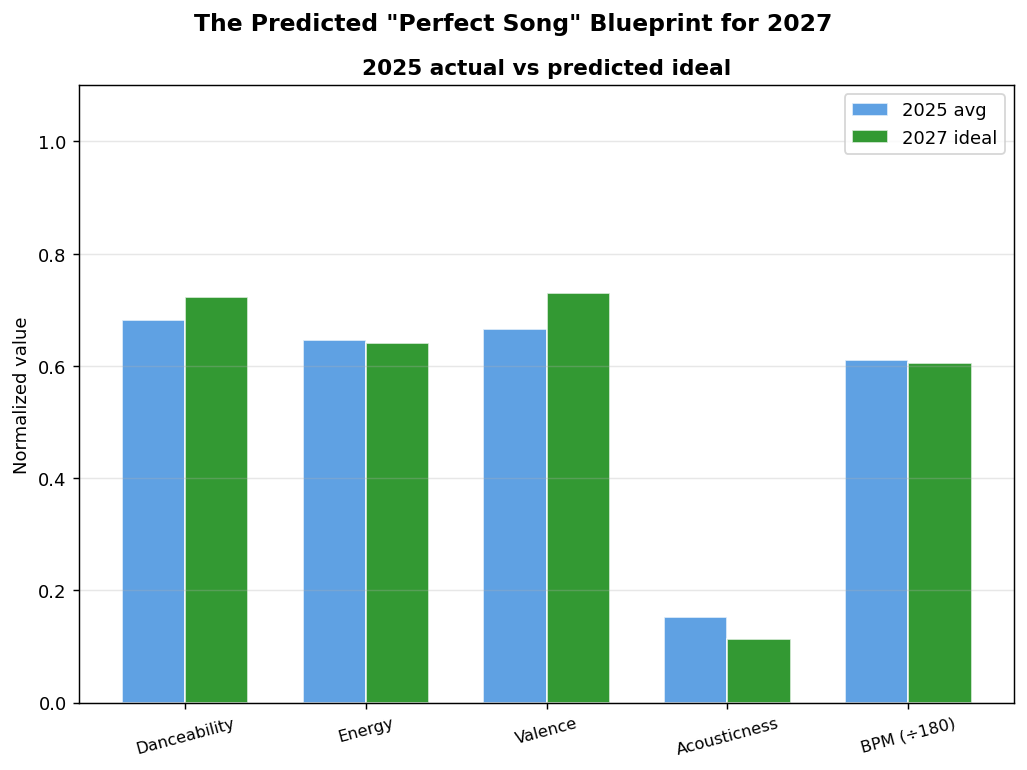


=== PREDICTED IDEAL SONG BLUEPRINT FOR 2027 ===
  Danceability : 0.722  (high — keep it moving)
  Energy       : 0.641  (moderate-high intensity)
  Valence      : 0.729  (positive, feel-good tone)
  Acousticness : 0.114  (mostly produced, some organic)
  BPM          : 109     (moderate tempo)


In [31]:
target_yr = 2027
perfect = {feat: trend_results[feat]['future'][target_yr] for feat in features}
perfect['bpm'] = trend_results['bpm']['future'][target_yr]

# Compare to 2025 actuals
actuals_25 = {feat: df_25[feat].mean() for feat in features}
actuals_25['bpm'] = df_25['bpm'].mean()

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
fig.suptitle(f'The Predicted "Perfect Song" Blueprint for {target_yr}', fontsize=13, fontweight='bold')

# Bar chart comparison
feat_show = features + ['bpm']
feat_labels = ['Danceability', 'Energy', 'Valence', 'Acousticness', 'BPM (÷180)']
vals_2025 = [actuals_25[f] if f != 'bpm' else actuals_25['bpm']/180 for f in feat_show]
vals_pred  = [perfect[f]   if f != 'bpm' else perfect['bpm']/180    for f in feat_show]

x = np.arange(len(feat_show))
w = 0.35
b1 = ax.bar(x - w/2, vals_2025, w, label='2025 avg', color='#378ADD', alpha=0.8, edgecolor='white')
b2 = ax.bar(x + w/2, vals_pred,  w, label=f'{target_yr} ideal', color='green', alpha=0.8, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(feat_labels, fontsize=9, rotation=15)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Normalized value')
ax.legend(fontsize=10)
ax.set_title('2025 actual vs predicted ideal', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('perfect_song_blueprint.png', bbox_inches='tight')
plt.show()

print(f'\n=== PREDICTED IDEAL SONG BLUEPRINT FOR {target_yr} ===')
print(f'  Danceability : {perfect["danceability"]:.3f}  (high — keep it moving)')
print(f'  Energy       : {perfect["energy"]:.3f}  (moderate-high intensity)')
print(f'  Valence      : {perfect["valence"]:.3f}  (positive, feel-good tone)')
print(f'  Acousticness : {perfect["acousticness"]:.3f}  (mostly produced, some organic)')
print(f'  BPM          : {perfect["bpm"]:.0f}     (moderate tempo)')

## 8. Genre-Specific Future Recommendations

In [32]:
genre_25 = df_25.groupby('primary_genre')[features + ['bpm', 'streams_2025_billions']].mean().round(3)
genre_25['n_songs'] = df_25.groupby('primary_genre').size()
top_genres = genre_25[genre_25['n_songs'] >= 2].sort_values('streams_2025_billions', ascending=False).head(8)

print('=== Per-Genre Hit Score for 2027 Ideal ===')
print(f'{"Genre":<18} {"Streams":>10} {"Score":>8} {"Verdict"}')
print('-' * 65)
for genre, row in top_genres.iterrows():
    s = hit_score.__wrapped__ if hasattr(hit_score,'__wrapped__') else hit_score
    score = 0
    ideal = {feat: trend_results[feat]['future'][2027] for feat in features}
    ideal_bpm_n = (trend_results['bpm']['future'][2027] - 60) / 120
    weights = dict(danceability=0.30, valence=0.25, energy=0.20, bpm=0.15, acousticness=0.10)
    uv = dict(danceability=row['danceability'], energy=row['energy'], valence=row['valence'],
              acousticness=row['acousticness'], bpm=(row['bpm']-60)/120)
    iv = dict(danceability=ideal['danceability'], energy=ideal['energy'], valence=ideal['valence'],
              acousticness=ideal['acousticness'], bpm=ideal_bpm_n)
    for feat, w in weights.items():
        score += (1 - abs(uv[feat] - iv[feat])) * w
    final = min(99, round(score * 100))
    print(f'{genre:<18} {row["streams_2025_billions"]:>10.3f}B {final:>8}/100')

=== Per-Genre Hit Score for 2027 Ideal ===
Genre                 Streams    Score Verdict
-----------------------------------------------------------------
K-Pop/Pop               1.370B       84/100
Pop                     1.126B       96/100
Hip-Hop                 1.020B       91/100
Country/Pop             0.975B       98/100
Pop Rock                0.955B       84/100
Indie Pop               0.890B       87/100
R&B/Pop                 0.885B       89/100
Reggaeton               0.875B       92/100
